In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

import quant

In [2]:
START = datetime(1997, 1, 18)
END = datetime(2026, 1, 17)

In [3]:
CONFIG_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "lseg-data.config.json"
VIX_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "data" / "vix.csv"
session = quant.SessionProvider(CONFIG_PATH)

In [4]:
with session as client:
    bonds = client.bonds.list_securities("Altria Group Inc")
    stocks = client.equities.list_securities("Altria Group Inc")

In [5]:
for bond in bonds:
    print(f"{bond.name} ({bond.ric})")

print("#" * 20)
    
for stock in stocks:
    print(f"{stock.name} ({stock.ric})")


Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 2.625 16-Sep-2026 (02209SAU7=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 7.75 15-Jan-2027 (718154CF2=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, MO 2.2 15-Jun-2027 (US184344319=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.875 04-Feb-2028 (02209SBS1=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 6.2 01-Nov-2028 (02209SBQ5=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.8 14-Feb-2029 (02209SBD4=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 3.4 06-May-2030 (02209SBJ1=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.5 06-Aug-2030 (02209SBU6=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, MO 3.125 15-Jun-2031 (US184344378=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 2.45 04-Feb-2032 (02209SBL6=)
Altria Group Inc, Plain Vanilla Fixed 

In [6]:
RIC_EXAMPLE = '718154CF2='
RIC_STOCK = 'MO'

bond_l1 = next(filter(lambda bond: bond.ric == RIC_EXAMPLE, bonds))
common_stock_l1 = next(filter(lambda stock: stock.ric == RIC_STOCK, stocks))

print(bond_l1)
print(common_stock_l1)

BondL1(name='Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 7.75 15-Jan-2027', ric='718154CF2=', perm_id='15628387220', pi='0x0000fa000d2d5288', business_entity='INSTRUMENTxFIXEDINCOMExGOVCORP')
EquityL1(name='Altria Group Inc, Ordinary Share, NYSE Consolidated', ric='MO', perm_id='55839269969', pi='1097565', business_entity='QUOTExEQUITY')


In [7]:
with session as client:
    bond_df = client.bonds.history_df(RIC_EXAMPLE, fields=[
                                                "TR.ZSPREAD", 
                                                "TR.OPTIONADJUSTEDSPREADBID",
                                                "TR.MODIFIEDDURATION",
                                                "TR.CONVEXITY",
                                                "TR.BASISPOINTVALUE",
                                                "TR.INTERPOLATEDGOVERNMENTSPREAD",
                                            ],
                                            interval=quant.Interval.DAY_1,
                                            start=START,
                                            end=END,
                                      )
    
    common_stock_df = client.equities.history_df(common_stock_l1, fields=[
                                                        "BID",
                                                        "ASK",
                                                        "TR.CompanyMarketCap",
                                                        # "TR.F.ITMShrFulDilComShrOutstTot", 
                                                        "TR.H.PriceToBVPerShare",
                                                        "TR.F.NetDebt",                                                        
                                                        "TR.F.NetCashFlowOp",
                                                        "TR.F.STDebtCurrPortOfLTDebt",
                                                        "TR.F.DebtLTTot",
                                                        "TR.F.EBITDA",
                                                        "TR.F.TotAssets",
                                                    ],
                                                    interval=quant.Interval.DAY_1,
                                                    start=START,
                                                    end=END,
                                                )
    
    
common_stock_df = common_stock_df.ffill().rename(columns={"BID": "MO_Bid", "ASK": "MO_Ask"})
bond_df = bond_df.ffill()

/Users/mateo/Code/quant/.venv/lib/python3.13/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [8]:
bond_df.columns

Index(['Z Spread', 'Option Adjusted Spread Bid', 'Modified Duration',
       'Convexity', 'Basis Point Value', 'Interpolated Government Spread'],
      dtype='object', name='718154CF2=')

In [9]:
bond_df

718154CF2=,Z Spread,Option Adjusted Spread Bid,Modified Duration,Convexity,Basis Point Value,Interpolated Government Spread
Date,,,,,,
2004-09-13,<NA>,<NA>,10.709,175.64,11.426,<NA>
2004-09-14,<NA>,<NA>,10.709,175.64,11.426,<NA>
2004-09-15,<NA>,<NA>,10.724,176.05,11.511,<NA>
2004-09-16,<NA>,<NA>,10.775,177.3,11.678,<NA>
2004-09-17,<NA>,<NA>,10.736,176.33,11.561,<NA>
...,...,...,...,...,...,...
2026-01-12,93.2438,93.2438,0.9312,1.3632,0.9974,89.6124
2026-01-13,66.0299,66.0299,0.9298,1.3603,0.9983,65.616
2026-01-14,67.0179,67.0179,0.9618,1.4046,0.9954,66.253


In [10]:
common_stock_df.columns

Index(['Price To Book Value Per Share(Time Series Ratio)', 'MO_Bid', 'MO_Ask',
       'Company Market Cap', 'Net Debt',
       'Net Cash Flow from Operating Activities',
       'Short-Term Debt & Current Portion of Long-Term Debt',
       'Debt - Long-Term - Total',
       'Earnings before Interest Taxes Depreciation & Amortization',
       'Total Assets'],
      dtype='object', name='MO')

In [11]:
common_stock_df

MO,Price To Book Value Per Share(Time Series Ratio),MO_Bid,MO_Ask,Company Market Cap,Net Debt,Net Cash Flow from Operating Activities,Short-Term Debt & Current Portion of Long-Term Debt,Debt - Long-Term - Total,Earnings before Interest Taxes Depreciation & Amortization,Total Assets
Date,,,,,,,,,,
1995-12-31,<NA>,<NA>,<NA>,<NA>,14688000000,6687000000,2719000000,13107000000,12788000000,53811000000
1996-12-31,<NA>,<NA>,<NA>,<NA>,15000000000,7634000000,2279000000,12961000000,14054000000,54871000000
1997-01-20,1.539472,9.026918,9.046207,95488285212.249893,15000000000,7634000000,2279000000,12961000000,14054000000,54871000000
1997-01-21,1.570656,9.210157,9.229446,97422482887.124893,15000000000,7634000000,2279000000,12961000000,14054000000,54871000000
1997-01-22,1.573938,9.229446,9.248734,97626082642.375,15000000000,7634000000,2279000000,12961000000,14054000000,54871000000
...,...,...,...,...,...,...,...,...,...,...
2026-01-12,-37.149486,58.52,58.53,98014593106.380005,21799000000,8753000000,1527000000,23399000000,12023000000,35177000000
2026-01-13,-38.171192,60.13,60.14,100710245564.550003,21799000000,8753000000,1527000000,23399000000,12023000000,35177000000
2026-01-14,-39.008864,61.48,61.49,102920345716.589996,21799000000,8753000000,1527000000,23399000000,12023000000,35177000000


In [12]:
with session as client:
    historical_iv = client.equities.historical_iv(
        "MO", 
        interval=quant.Interval.DAY_1,
        start=START,
        end=END,
    )

/Users/mateo/Code/quant/.venv/lib/python3.13/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [13]:
historical_iv.df

MOATMIV.U,30D_A_IM_C,30D_A_IM_P,60D_A_IM_C,60D_A_IM_P,90D_A_IM_C,90D_A_IM_P
Date,,,,,,
2006-05-08,21.24,21.64,21.95,22.12,21.91,22.13
2006-05-09,22.05,20.38,22.5,21.45,22.79,21.97
2006-05-10,24.85,25.15,24.51,24.82,24.48,24.65
2006-05-11,24.09,24.45,24.37,24.94,24.49,25.0
2006-05-12,23.08,24.9,23.91,25.37,24.12,25.2
...,...,...,...,...,...,...
2026-01-12,20.87,20.87,20.0,20.0,19.88,19.88
2026-01-13,18.53,18.53,19.41,19.41,19.32,19.32
2026-01-14,21.09,21.09,19.34,19.34,19.2,19.2


In [14]:
vix = pd.read_csv(VIX_PATH, sep='\t', parse_dates=True, index_col=0).rename(columns={"Close": "VIX_Close"})

vix = vix[(START < vix.index) & (vix.index < END)]

vix

,VIX_Close
Date,
1997-01-20,18.60
1997-01-21,17.81
1997-01-22,17.09
1997-01-23,18.47
1997-01-24,19.33
...,...
2026-01-12,15.12
2026-01-13,15.98
2026-01-14,16.75


In [15]:
working_df = vix.join(common_stock_df).join(bond_df).join(historical_iv.df)

working_df.dropna()

working_df = working_df[~working_df.index.duplicated(keep='first')]

working_df

,VIX_Close,Price To Book Value Per Share(Time Series Ratio),MO_Bid,MO_Ask,Company Market Cap,Net Debt,Net Cash Flow from Operating Activities,Short-Term Debt & Current Portion of Long-Term Debt,Debt - Long-Term - Total,Earnings before Interest Taxes Depreciation & Amortization,...,Modified Duration,Convexity,Basis Point Value,Interpolated Government Spread,30D_A_IM_C,30D_A_IM_P,60D_A_IM_C,60D_A_IM_P,90D_A_IM_C,90D_A_IM_P
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-20,18.60,1.539472,9.026918,9.046207,95488285212.249893,15000000000,7634000000,2279000000,12961000000,14054000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1997-01-21,17.81,1.570656,9.210157,9.229446,97422482887.124893,15000000000,7634000000,2279000000,12961000000,14054000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1997-01-22,17.09,1.573938,9.229446,9.248734,97626082642.375,15000000000,7634000000,2279000000,12961000000,14054000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1997-01-23,18.47,1.544396,9.065495,9.084783,95793684845.125,15000000000,7634000000,2279000000,12961000000,14054000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1997-01-24,19.33,1.519778,8.920833,8.949765,94266686680.75,15000000000,7634000000,2279000000,12961000000,14054000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-12,15.12,-37.149486,58.52,58.53,98014593106.380005,21799000000,8753000000,1527000000,23399000000,12023000000,...,0.9312,1.3632,0.9974,89.6124,20.87,20.87,20.0,20.0,19.88,19.88
2026-01-13,15.98,-38.171192,60.13,60.14,100710245564.550003,21799000000,8753000000,1527000000,23399000000,12023000000,...,0.9298,1.3603,0.9983,65.616,18.53,18.53,19.41,19.41,19.32,19.32
2026-01-14,16.75,-39.008864,61.48,61.49,102920345716.589996,21799000000,8753000000,1527000000,23399000000,12023000000,...,0.9618,1.4046,0.9954,66.253,21.09,21.09,19.34,19.34,19.2,19.2


In [16]:
eq_value = working_df["Company Market Cap"]
eq_vol = ((working_df["MO_Bid"] + working_df["MO_Ask"]) / 2.0).pct_change().rolling(60, min_periods=20).std() * (252 ** 0.5)
common_idx = eq_value.index.intersection(eq_vol.index)

panel = pd.DataFrame({
    "equity_value":      eq_value,
    "equity_volatility": eq_vol,
    "short_term_debt":   working_df["Short-Term Debt & Current Portion of Long-Term Debt"],
    "long_term_debt":    working_df["Debt - Long-Term - Total"],
    "z_spread":          working_df["Z Spread"].mean()
}, index=common_idx).dropna()

panel = panel[(panel["equity_volatility"] > 0) & 
              (panel["equity_value"] > 0) & 
              (panel["short_term_debt"] + panel["long_term_debt"] > 0)]

risk_free_rate_decimal = 0.045

base_inputs = quant.kmv.KMVInputs(
    equity_value=1.0, 
    equity_volatility=0.1, 
    short_term_debt=1.0, 
    long_term_debt=1.0, 
    risk_free_rate=risk_free_rate_decimal
)

ts = quant.kmv_timeseries.build_from_panel(panel, base_inputs=base_inputs, name="Altria Group (MO)")

/var/folders/5t/tbhys9bs5z50rr8f8h42bmyw0000gn/T/ipykernel_64613/1762450571.py:2:FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


In [17]:
ts

KMVTimeSeries(name='Altria Group (MO)', n=7254, dates=1997-02-18 00:00:00→2026-01-16 00:00:00)

/Users/mateo/Code/quant/quant/series_group.py:161:UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


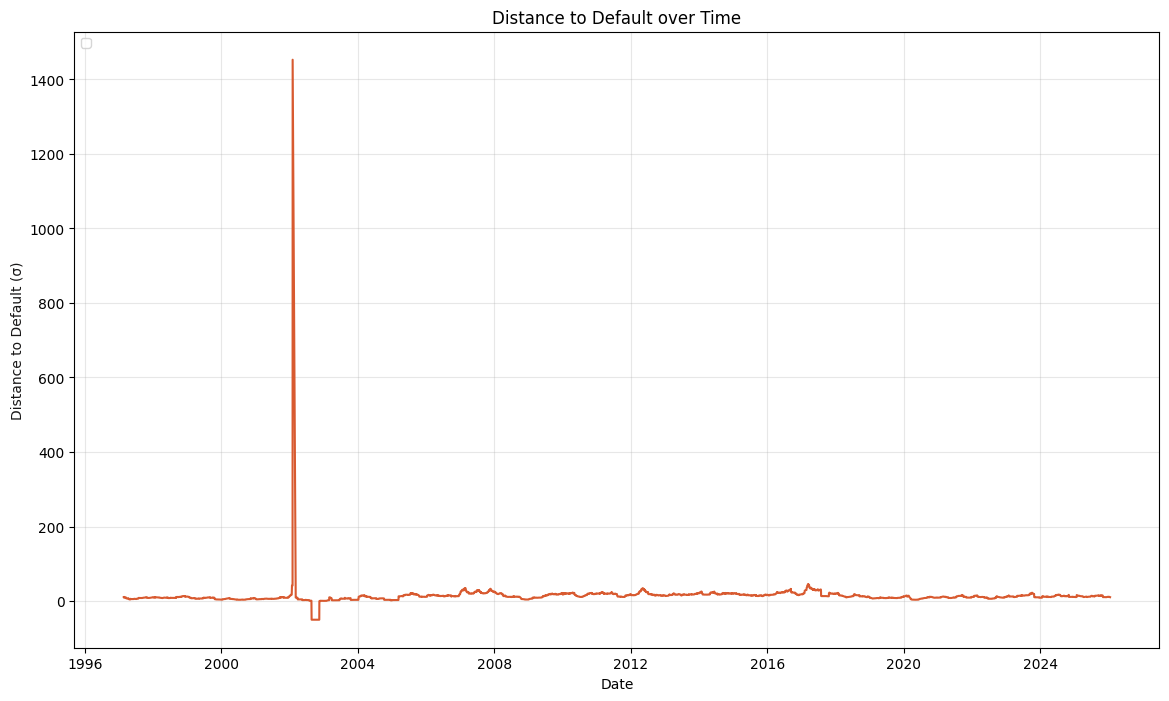

In [18]:
sg = quant.SeriesGroup(
    [ts.dd_series()],
    labels={"title": "Distance to Default over Time", "ylabel_primary": "Distance to Default (σ)"},
)
sg.plot()

plt.show()

In [23]:
working_df_dd = working_df.join(ts.dd_series()).join(ts.basis_series()).join(ts.edf_series()).dropna()
working_df_dd

,VIX_Close,Price To Book Value Per Share(Time Series Ratio),MO_Bid,MO_Ask,Company Market Cap,Net Debt,Net Cash Flow from Operating Activities,Short-Term Debt & Current Portion of Long-Term Debt,Debt - Long-Term - Total,Earnings before Interest Taxes Depreciation & Amortization,...,Interpolated Government Spread,30D_A_IM_C,30D_A_IM_P,60D_A_IM_C,60D_A_IM_P,90D_A_IM_C,90D_A_IM_P,dd,basis_bps,edf_pct
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-15,27.02,38.846853,57.19,57.2,112115402313.199997,10478000000,5843000000,4000000,12843000000,8631000000,...,123.4458,23.48,23.48,21.5,21.5,21.17,21.17,15.603597,214.051184,0.04
2016-01-19,26.05,39.661822,58.4,58.41,114467473690.399994,10478000000,5843000000,4000000,12843000000,8631000000,...,123.2495,22.11,22.11,21.62,21.62,21.29,21.29,15.339676,214.051184,0.04
2016-01-20,27.59,38.860436,57.21,57.22,112154603502.819,10478000000,5843000000,4000000,12843000000,8631000000,...,125.0509,25.29,25.29,23.34,23.34,22.7,22.7,14.997837,214.051184,0.04
2016-01-21,26.69,39.016638,57.45,57.46,112605417183.449997,10478000000,5843000000,4000000,12843000000,8631000000,...,125.1433,23.61,23.61,22.43,22.43,22.09,22.09,14.999573,214.051184,0.04
2016-01-22,22.34,39.580325,58.27,58.28,114232266552.679993,10478000000,5843000000,4000000,12843000000,8631000000,...,124.8558,21.05,21.05,19.22,19.22,20.04,20.04,15.094406,214.051184,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-12,15.12,-37.149486,58.52,58.53,98014593106.380005,21799000000,8753000000,1527000000,23399000000,12023000000,...,89.6124,20.87,20.87,20.0,20.0,19.88,19.88,10.636751,214.051184,0.04
2026-01-13,15.98,-38.171192,60.13,60.14,100710245564.550003,21799000000,8753000000,1527000000,23399000000,12023000000,...,65.616,18.53,18.53,19.41,19.41,19.32,19.32,10.401159,214.051184,0.04
2026-01-14,16.75,-39.008864,61.48,61.49,102920345716.589996,21799000000,8753000000,1527000000,23399000000,12023000000,...,66.253,21.09,21.09,19.34,19.34,19.2,19.2,10.300490,214.051184,0.04


In [24]:
working_df_dd.to_csv('./working_mo_df.csv')